In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv("results.csv")
df.columns


Index(['timestamp', 'device', 'gpu_name', 'batch_size', 'gpu_resident',
       'precision_requested', 'precision_effective', 'width', 'depth',
       'compile_model', 'num_workers', 'optimizer', 'base_lr', 'weight_decay',
       'warmup_steps', 'measure_steps', 'samples_per_sec', 'elapsed_s',
       'success', 'error', 'params_million', 'gpu_util_avg_pct',
       'gpu_util_max_pct', 'gpu_mem_used_avg_GiB', 'gpu_mem_used_max_GiB',
       'alloc_peak_GiB', 'reserved_peak_GiB'],
      dtype='object')

In [17]:
df.query("width == 128").groupby(["batch_size", "gpu_resident", "precision_requested", "width", "num_workers"]).agg(
    {"gpu_util_avg_pct": ["mean", "std"], "samples_per_sec": ["mean", "std"]}
)


gpu_util_avg_pct  \
                                                                          mean   
batch_size gpu_resident precision_requested width num_workers                    
2048       False        32-true             128   0                   3.420000   
                                                  4                   4.020000   
                                                  8                   6.230000   
                        bf16-mixed          128   0                   3.405000   
                                                  4                   5.630000   
                                                  8                   5.215000   
           True         32-true             128   0                   3.041667   
                        bf16-mixed          128   0                   3.315000   
8192       False        32-true             128   0                   2.165000   
                                                  4                   2.715000   
                                                  8                   3.370000   
                        bf16-mixed          128   0                   1.630000   
                                                  4                   1.580000   
                                                  8                   2.900000   
           True         32-true             128   0                   1.911667   
                        bf16-mixed          128   0                   1.805000   
16384      False        32-true             128   0                   1.270000   
                                                  4                   2.385000   
                                                  8                   1.590000   
                        bf16-mixed          128   0                   1.225000   
                                                  4                   1.375000   
                                                  8                   1.605000   
           True         32-true             128   0                   1.481667   
                        bf16-mixed          128   0                   1.466667   
32768      True         32-true             128   0                   1.243333   
                        bf16-mixed          128   0                   1.220000   

                                                                         \
                                                                    std   
batch_size gpu_resident precision_requested width num_workers             
2048       False        32-true             128   0                 NaN   
                                                  4                 NaN   
                                                  8                 NaN   
                        bf16-mixed          128   0                 NaN   
                                                  4                 NaN   
                                                  8                 NaN   
           True         32-true             128   0            0.366413   
                        bf16-mixed          128   0            0.063836   
8192       False        32-true             128   0                 NaN   
                                                  4                 NaN   
                                                  8                 NaN   
                        bf16-mixed          128   0                 NaN   
                                                  4                 NaN   
                                                  8                 NaN   
           True         32-true             128   0            0.002887   
                        bf16-mixed          128   0            0.057663   
16384      False        32-true             128   0                 NaN   
                                                  4                 NaN   
                                                  8                 NaN   
                        bf16-mixe

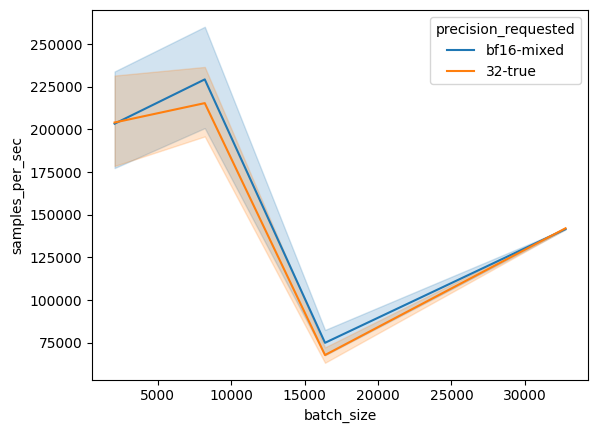

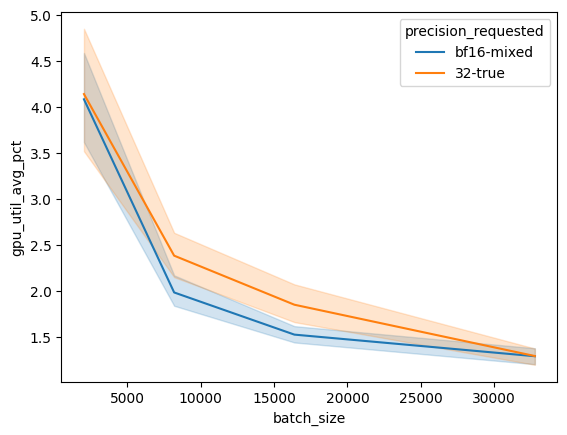

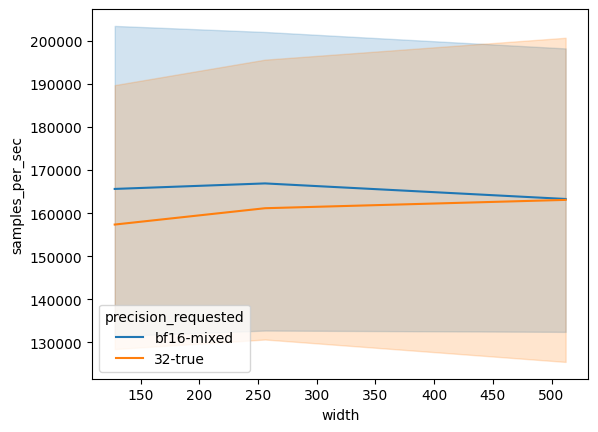

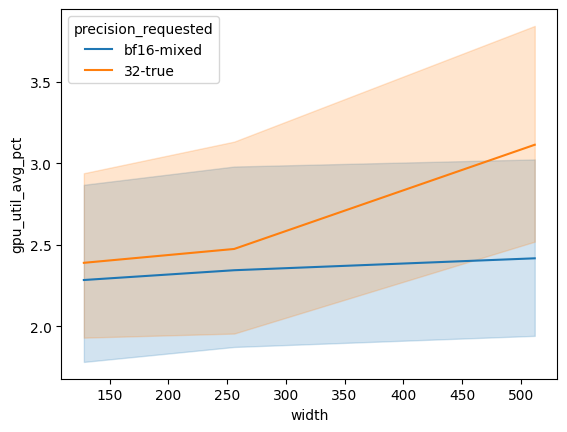

In [20]:
# show how samples per second changes with batch size
sns.lineplot(data=df, x="batch_size", y="samples_per_sec", hue="precision_requested")
plt.show()

sns.lineplot(data=df, x="batch_size", y="gpu_util_avg_pct", hue="precision_requested")
plt.show()

# with width
sns.lineplot(data=df, x="width", y="samples_per_sec", hue="precision_requested")
plt.show()

sns.lineplot(data=df, x="width", y="gpu_util_avg_pct", hue="precision_requested")
plt.show()




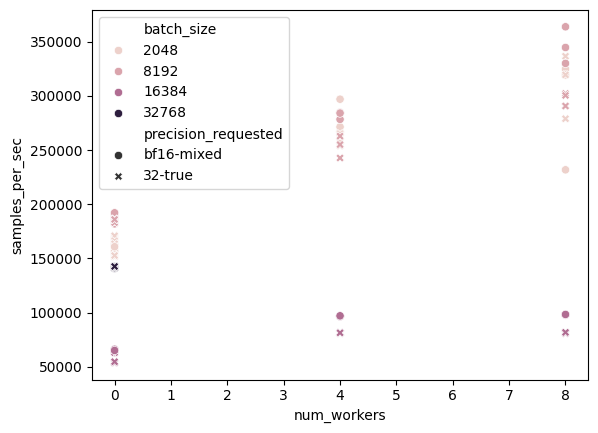

In [26]:
# speed as a function of num_workers, colored by gpu_resident
sns.scatterplot(data=df, x="num_workers", y="samples_per_sec", hue="batch_size", style="precision_requested")
plt.show()
